In [1]:
from sklearn.datasets import load_diabetes

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")


In [2]:
data = load_diabetes()

df = pd.DataFrame(data.data,columns=data.feature_names)
df['target'] = data.target

In [3]:
df.columns

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6',
       'target'],
      dtype='object')

In [4]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [5]:
X_train,X_test,y_train,y_test = train_test_split(
    data.data,data.target,test_size=0.2,random_state= 42)

# How coefficients are affected?

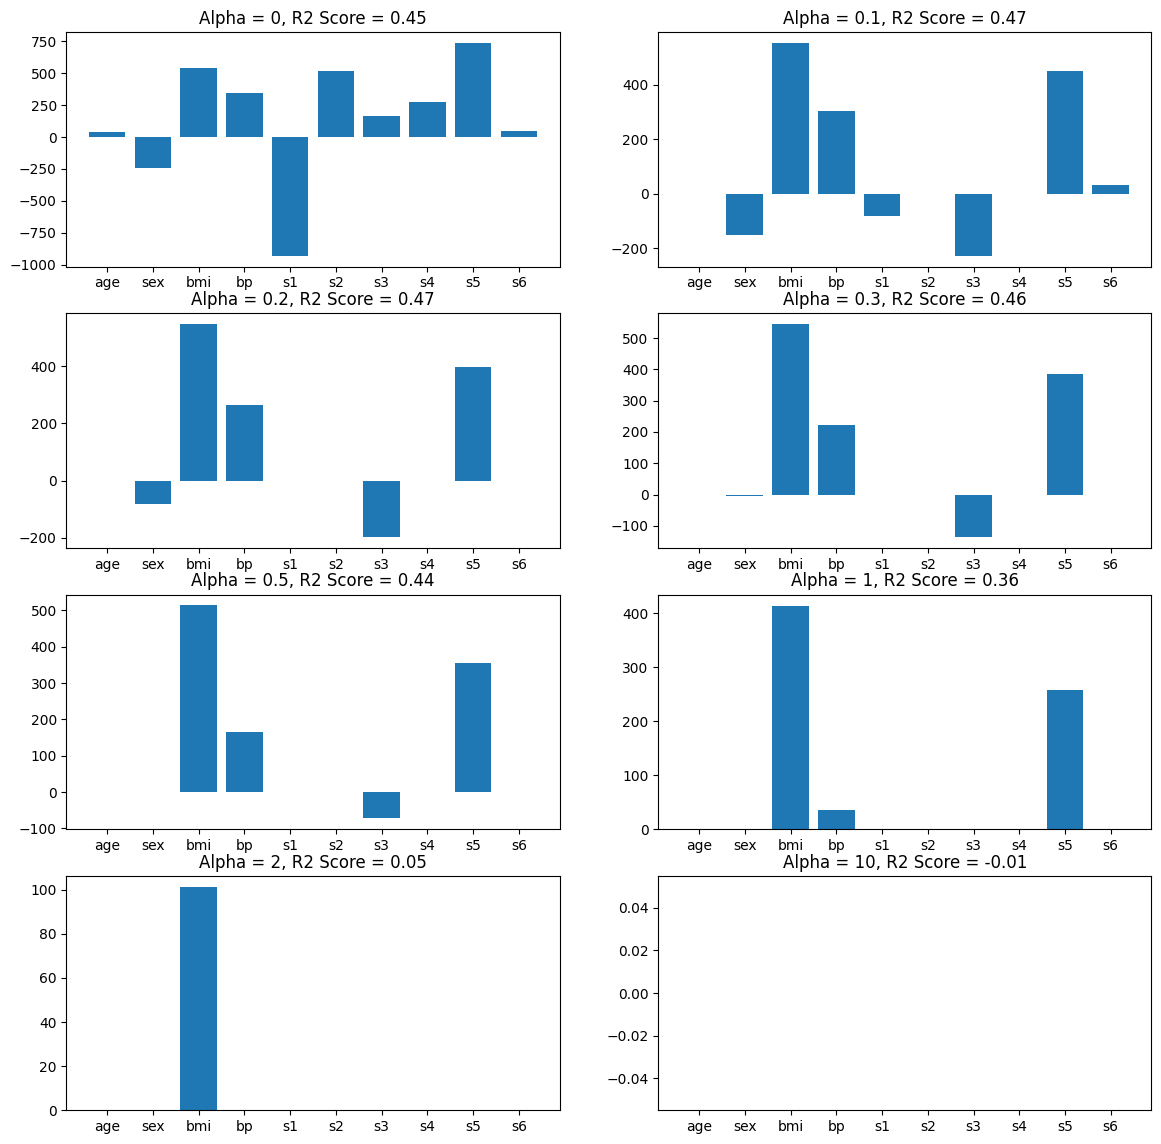

In [6]:
coefficients = [] 
r2_scores = []
alphas = [0,0.1,0.2,0.3,0.5,1,2,10]

for alpha in alphas:
     lo = Lasso(alpha = alpha) 
     lo.fit(X_train, y_train) 
     coefficients.append(lo.coef_.tolist()) 
     y_pred = lo.predict(X_test) 
     r2_scores.append(r2_score(y_test,y_pred)) 
    
plt.figure(figsize=(14,14)) 

for i in range(8):
    
    plt.subplot(4,2,i+1) 
    plt.bar(data.feature_names,coefficients[i])
    plt.title(f"Alpha = {alphas[i]}, R2 Score = {round(r2_scores[i],2)}")
    


# Higher ccoefficients are affected more! 

In [7]:
alphaaaas = [0,0.1,0.3,0.5,1,3,5,7,10,15,20]
coefs = [] 

for alpha in alphaaaas: 
    lasso = Lasso(alpha = alpha)
    lasso.fit(X_train,y_train) 
    coefs.append(lasso.coef_.tolist()) 

coef_array = np.array(coefs)

coef_df = pd.DataFrame(coef_array, columns = data.feature_names) 
coef_df['alpha'] = alphaaaas
coef_df.set_index('alpha')

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
alpha,,,,,,,,,,
0.0,37.904021,-241.964362,542.428759,347.703844,-931.488838,518.062271,163.419980,275.317901,736.198856,48.670657
0.1,0.000000,-152.664779,552.697775,303.365158,-81.365007,-0.000000,-229.255776,0.000000,447.919525,29.642617
0.3,0.000000,-6.017296,544.399947,221.736426,-0.000000,-0.000000,-136.369280,0.000000,384.020428,0.000000
0.5,0.000000,-0.000000,513.587467,165.497563,-0.000000,-0.000000,-72.683391,0.000000,354.650101,0.000000
1.0,0.000000,-0.000000,413.431848,34.830515,0.000000,0.000000,-0.000000,0.000000,258.152894,0.000000
3.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000
5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000
7.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000
10.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000


In [8]:
alphaaaas

[0, 0.1, 0.3, 0.5, 1, 3, 5, 7, 10, 15, 20]

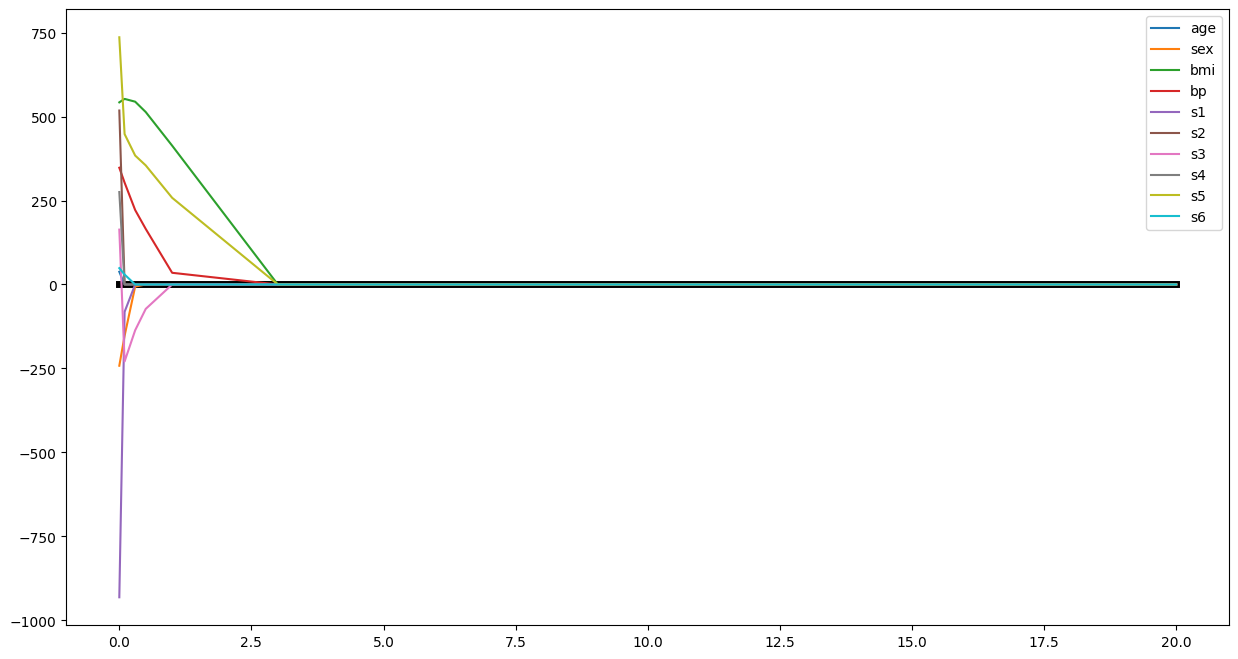

In [9]:

input_array = np.array(coefs).T

plt.figure(figsize=(15,8))
plt.plot(alphaaaas,np.zeros(len(alphaaaas)),color='black',linewidth=5)
for i in range(input_array.shape[0]):
    plt.plot(alphaaaas,input_array[i],label=data.feature_names[i])
plt.legend()



# Impact on Bias and Variance 

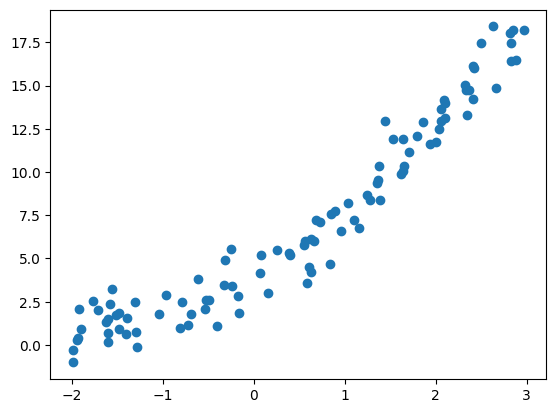

In [10]:
x1= 5*np.random.rand(100,1) - 2 
y1 = 0.7*x1**2 + 3*x1 + 4 + np.random.randn(100,1) 

plt.scatter(x1,y1)

In [15]:
X1_train, X1_test, y1_train,y1_test = train_test_split(
    x1.reshape(100,1),y1.reshape(100), test_size=0.2, random_state= 42)

In [18]:
from sklearn.preprocessing import PolynomialFeatures 

pf = PolynomialFeatures(degree=5) 

X_train1 = pf.fit_transform(X1_train) 
X_test1 = pf.transform(X1_test)

In [20]:
print(pf.n_output_features_)

6


In [21]:
from mlxtend.evaluate import bias_variance_decomp

alphas = np.linspace(0,30,100)

loss = []
bias = []
variance = []

for i in alphas:
    reg = Lasso(alpha=i)
    avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(
        reg, X_train, y_train, X_test, y_test, 
        loss='mse',
        random_seed=123)
    loss.append(avg_expected_loss)
    bias.append(avg_bias)
    variance.append(avg_var)

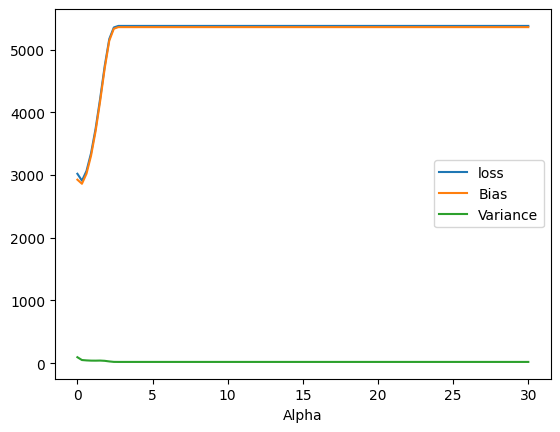

In [22]:
plt.plot(alphas,loss,label='loss')
plt.plot(alphas,bias,label='Bias')
plt.plot(alphas,variance,label='Variance')
plt.xlabel('Alpha')
plt.legend()

# Effect of Regularization on Loss Function

[27.82809103]
-2.29474455867698


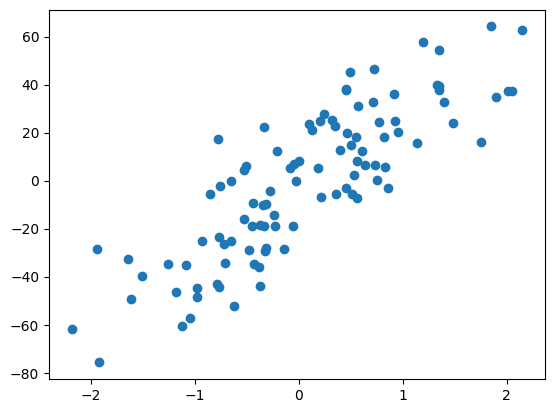

In [23]:
from sklearn.datasets import make_regression

X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

plt.scatter(X,y)

from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X,y)
print(reg.coef_)
print(reg.intercept_)

In [24]:
def cal_loss(m,alpha):
    return np.sum((y - m*X.ravel() + 2.29)**2) + alpha*abs(m)

In [25]:
def predict(m):
    return m*X - 2.29

Text(0, 0.5, 'Loss')

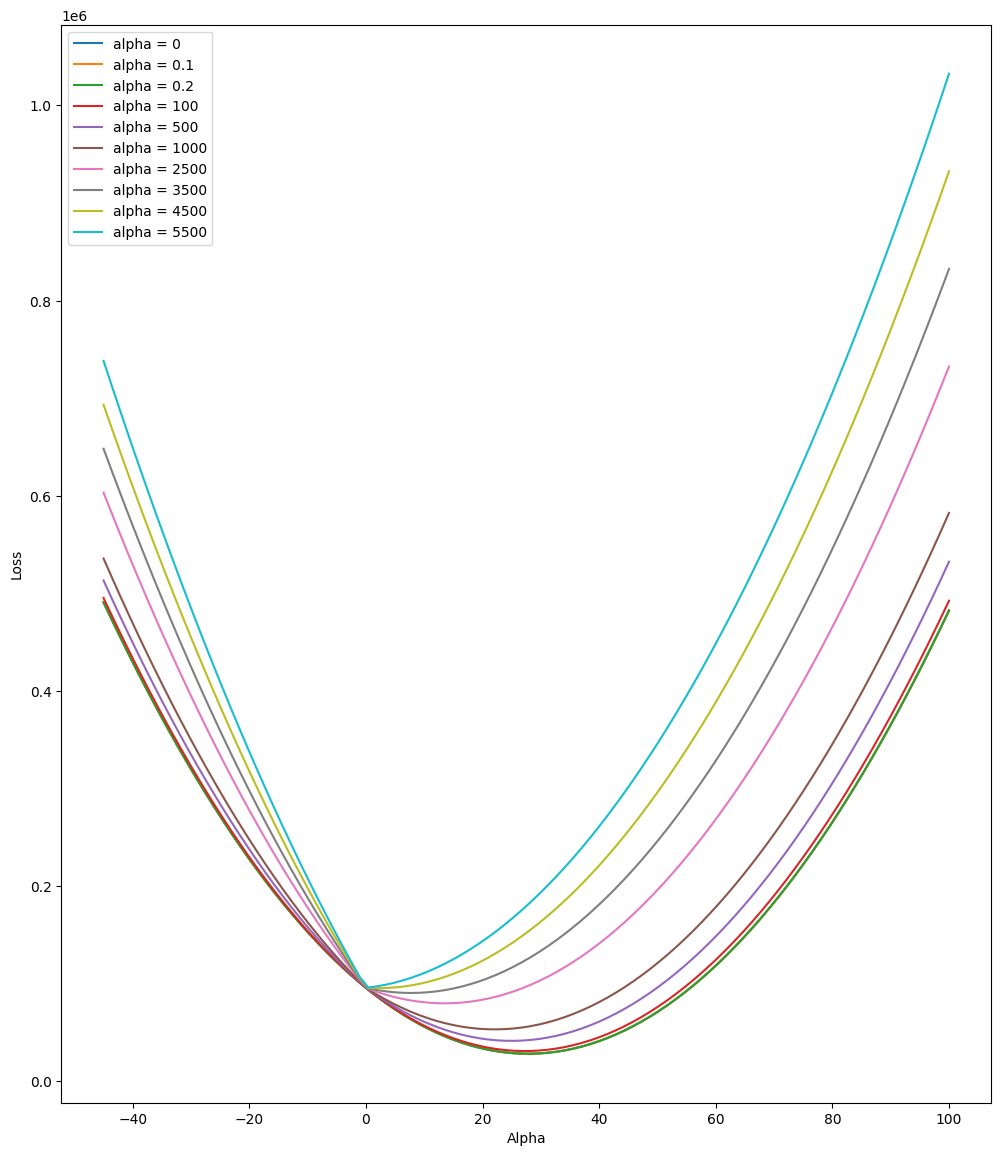

In [32]:
m = np.linspace(-45,100,100)
plt.figure(figsize=(12,14))
for j in [0,0.1,0.2,100,500,1000,2500,3500,4500,5500]:
    loss = []
    for i in range(m.shape[0]):
        loss_i = cal_loss(m[i],j)
        loss.append(loss_i)
    plt.plot(m,loss,label=f'alpha = {j}')
plt.legend()
plt.xlabel('Alpha')
plt.ylabel('Loss')